# Previsão de Contratos - 8 Semanas

Este notebook realiza uma previsão de 8 semanas para os novos contratos de aluguel de motos by filial, utilizando análise de séries temporais e modelos de aprendizado de máquina.

## 1. Load and Explore Data

Carregando os dados e examinando sua estrutura.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import plotly.graph_objects as go
import plotly.express as px

# Suppress warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ All required libraries imported successfully")

✅ All required libraries imported successfully


In [2]:
# Load data
df = pd.read_csv('data/raw/contratos_por_lugar_produto.csv')

print("📊 Dataset Shape:", df.shape)
print("\n📋 Columns:", df.columns.tolist())
print("\n🔍 First rows:")
print(df.head())
print("\n📈 Data Types:")
print(df.dtypes)
print("\n📊 Summary Statistics:")
print(df.describe())

📊 Dataset Shape: (28345, 7)

📋 Columns: ['periodo_bisemanal', 'lugar', 'lugarId', 'longitude_lugar', 'latitude_lugar', 'contratos_novos', 'tipo_moto']

🔍 First rows:
  periodo_bisemanal                     lugar  lugarId  longitude_lugar  \
0       2025-11-W23  Mottu São João de Meriti      314       -43.362295   
1       2025-11-W23           Mottu Messejana      402       -38.482752   
2       2025-11-W23     Mottu Duque de Caxias      469       -43.304415   
3       2025-11-W23           Mottu Cariacica      489       -40.397799   
4       2025-05-W10             Mottu Palhoça      296       -48.658054   

   latitude_lugar  contratos_novos tipo_moto  
0      -22.781795               49      Nova  
1       -3.837260               28      Nova  
2      -22.791526                7     Usada  
3      -20.342720               15     Usada  
4      -27.634887                5      Nova  

📈 Data Types:
periodo_bisemanal     object
lugar                 object
lugarId                int64

In [3]:
# Check missing values
print("🔎 Missing Values:")
print(df.isnull().sum())
print("\n🕐 Temporal Range:")
print(f"First period: {df['periodo_bisemanal'].min()}")
print(f"Last period: {df['periodo_bisemanal'].max()}")
print(f"\n📍 Number of unique locations: {df['lugar'].nunique()}")
print(f"📌 Number of unique tipo_moto: {df['tipo_moto'].nunique()}")

🔎 Missing Values:
periodo_bisemanal     0
lugar                 0
lugarId               0
longitude_lugar      15
latitude_lugar       15
contratos_novos       0
tipo_moto             0
dtype: int64

🕐 Temporal Range:
First period: 2024-01-W01
Last period: 2026-03-W06

📍 Number of unique locations: 469
📌 Number of unique tipo_moto: 4


## 2. Data Preprocessing and Cleaning

Filtrando dados de contratos novos e preparando para análise de séries temporais.

In [4]:

# First, let's examine all contract types and their distribution
print("📊 Contract Type Distribution:")
print(df['tipo_moto'].value_counts())
print(f"\nTotal unique types: {df['tipo_moto'].nunique()}")

# Use ALL contract types (not just 'Nova')
df_nova = df.copy()

print(f"\n📊 Original data: {len(df)} rows")
print(f"✅ Using all contract types: {len(df_nova)} rows")

# Remove invalid locations (missing lugar)
df_nova = df_nova[df_nova['lugar'].notna()].copy()

# Parse periodo_bisemanal to extract year and week
# Format: YYYY-MM-WXX (e.g., 2025-11-W23)
def parse_period(period_str):
    try:
        parts = period_str.split('-W')  # Split into ['YYYY-MM', 'XX']
        year_month = parts[0]  # 'YYYY-MM'
        week = int(parts[1])   # XX
        year = int(year_month.split('-')[0])  # Extract YYYY
        return year, week
    except:
        return None, None

df_nova[['ano', 'periodo']] = df_nova['periodo_bisemanal'].apply(
    lambda x: pd.Series(parse_period(x))
)

# Remove rows with parsing errors
df_nova = df_nova[df_nova['ano'].notna()].copy()

print(f"✅ Cleaned data: {len(df_nova)} rows")
print(f"\n📅 Data range: {df_nova['ano'].min()}-W{int(df_nova['periodo'].min())} to {df_nova['ano'].max()}-W{int(df_nova['periodo'].max())}")
print(f"\n📈 Contract types in final dataset:")
print(df_nova['tipo_moto'].value_counts())


📊 Contract Type Distribution:
tipo_moto
Nova         12530
Usada         7361
Semi-nova     6075
Outros        2379
Name: count, dtype: int64

Total unique types: 4

📊 Original data: 28345 rows
✅ Using all contract types: 28345 rows
✅ Cleaned data: 28345 rows

📅 Data range: 2024-W1 to 2026-W27

📈 Contract types in final dataset:
tipo_moto
Nova         12530
Usada         7361
Semi-nova     6075
Outros        2379
Name: count, dtype: int64


## 3. Aggregate Contracts by Location and Time Period

Agregando dados por filial e período bisemanal.



## Observação: Padrão Cíclico nos Dados

Os dados mostram uma tendência alternada (bem, não bem, bem, não bem...) em muitas filiais, sugerindo sazonalidade bisemanal ou comportamento cíclico. O modelo linear atual captura a tendência geral, mas pode subestimar essa volatilidade. Para previsões mais sofisticadas, considere ARIMA, Exponential Smoothing, ou modelos de sazonalidade.

In [5]:

# Aggregate contracts by location, period, and type
df_agg = df_nova.groupby(['lugar', 'periodo_bisemanal', 'tipo_moto']).agg({
    'contratos_novos': 'sum',
    'longitude_lugar': 'first',
    'latitude_lugar': 'first'
}).reset_index()

print("📊 Agregated data shape:", df_agg.shape)
print("\n🏪 Top 10 locations by total contracts (all types):")
top_locations = df_nova.groupby('lugar')['contratos_novos'].sum().sort_values(ascending=False).head(10)
print(top_locations)

# For each location, let's see which types of contracts are most prevalent
print("\n📈 Contract types by top 5 locations:")
for loc in top_locations.head(5).index:
    loc_data = df_nova[df_nova['lugar'] == loc]
    type_dist = loc_data.groupby('tipo_moto')['contratos_novos'].sum()
    print(f"\n{loc}:")
    print(type_dist)

# Filter for locations with sufficient data (at least 5 periods)
location_counts = df_nova.groupby('lugar').size()
locations_with_data = location_counts[location_counts >= 5].index.tolist()

print(f"\n✅ Locations with at least 5 periods: {len(locations_with_data)}")

df_agg_filtered = df_agg[df_agg['lugar'].isin(locations_with_data)].copy()
print(f"📊 Filtered data: {len(df_agg_filtered)} rows")


📊 Agregated data shape: (28345, 6)

🏪 Top 10 locations by total contracts (all types):
lugar
Mottu São Miguel      10679
Mottu Fortaleza        9255
Mottu Belém            8831
Mottu São Luís         8629
Mottu Butantã          8063
Mottu Teresina         7364
Mottu Salvador         7332
Mottu São Bernardo     7277
Mottu Natal            6724
Mottu Taboão           6186
Name: contratos_novos, dtype: int64

📈 Contract types by top 5 locations:

Mottu São Miguel:
tipo_moto
Nova         1695
Outros       1407
Semi-nova    1804
Usada        5773
Name: contratos_novos, dtype: int64

Mottu Fortaleza:
tipo_moto
Nova         2989
Outros        531
Semi-nova    1215
Usada        4520
Name: contratos_novos, dtype: int64

Mottu Belém:
tipo_moto
Nova         3788
Outros        736
Semi-nova     593
Usada        3714
Name: contratos_novos, dtype: int64

Mottu São Luís:
tipo_moto
Nova         4022
Outros        164
Semi-nova     635
Usada        3808
Name: contratos_novos, dtype: int64

Mottu Butant

## 4. Time Series Analysis and Visualization

Analisando tendências históricas e padrões de sazonalidade.

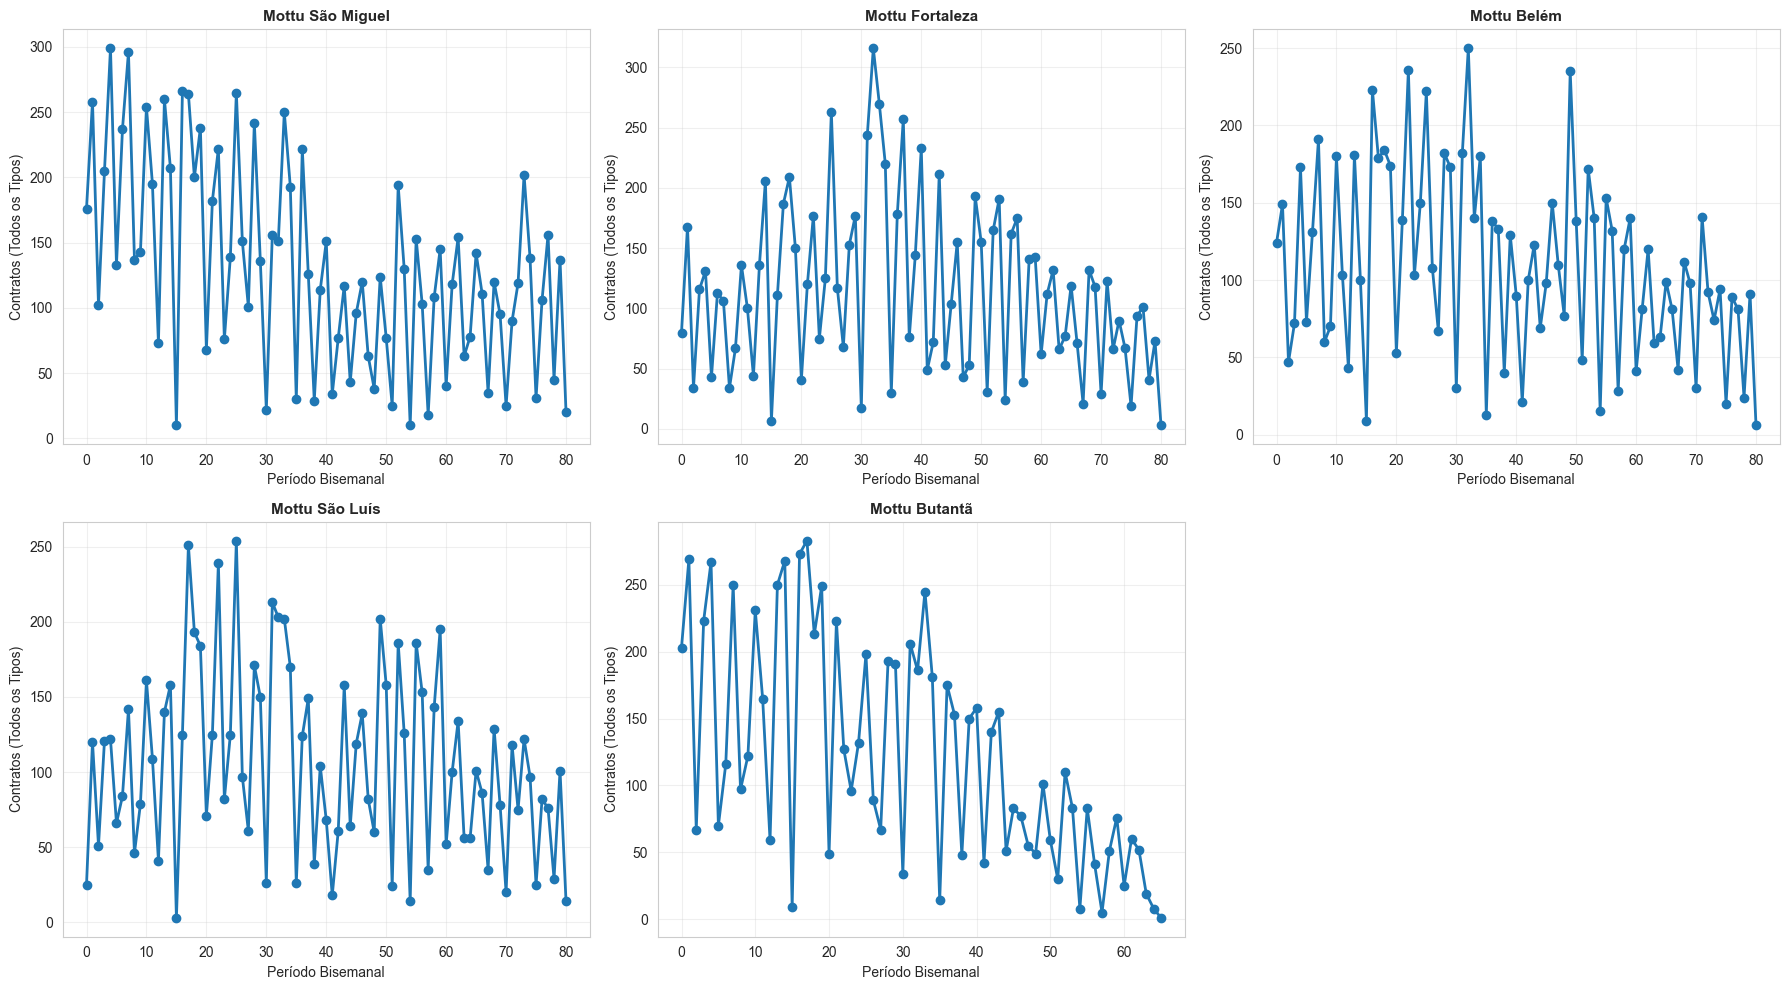

✅ Time series visualization saved!


In [6]:

# Sort by period for proper time series visualization
# Aggregate by location and period (summing all contract types)
df_ts = df_nova.groupby(['lugar', 'periodo_bisemanal']).agg({
    'contratos_novos': 'sum'
}).reset_index().sort_values('periodo_bisemanal')

# Get top 5 locations
top_5_locations = df_nova.groupby('lugar')['contratos_novos'].sum().sort_values(ascending=False).head(5).index.tolist()

# Visualize top 5 locations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, location in enumerate(top_5_locations):
    data = df_ts[df_ts['lugar'] == location].sort_values('periodo_bisemanal')
    axes[idx].plot(range(len(data)), data['contratos_novos'].values, marker='o', linewidth=2)
    axes[idx].set_title(f'{location}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Período Bisemanal')
    axes[idx].set_ylabel('Contratos (Todos os Tipos)')
    axes[idx].grid(True, alpha=0.3)

# Hide the last subplot if not used
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('data/processed/01_ts_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Time series visualization saved!")


## 5. Train Forecasting Models

Treinando modelos de previsão usando exponential smoothing e regressão linear.

In [7]:

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Dictionary to store models and performance metrics
models_performance = {}

# Train models for each location (all contract types combined)
for location in top_5_locations:
    data = df_ts[df_ts['lugar'] == location].copy()
    data = data.sort_values('periodo_bisemanal').reset_index(drop=True)
    
    if len(data) < 3:
        continue
    
    X = np.arange(len(data)).reshape(-1, 1)
    y = data['contratos_novos'].values
    
    # Train-test split (80-20)
    split_idx = int(0.8 * len(data))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Calculate metrics
    y_pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    
    models_performance[location] = {
        'model': model,
        'rmse': rmse,
        'mae': mae,
        'data': data,
        'last_period': data['periodo_bisemanal'].iloc[-1]
    }
    
    print(f"📍 {location}: RMSE={rmse:.2f}, MAE={mae:.2f}, Data Points={len(data)}")

print(f"\n✅ Models trained for {len(models_performance)} locations")


📍 Mottu São Miguel: RMSE=69.61, MAE=56.48, Data Points=81
📍 Mottu Fortaleza: RMSE=72.36, MAE=61.02, Data Points=81
📍 Mottu Belém: RMSE=44.50, MAE=33.40, Data Points=81
📍 Mottu São Luís: RMSE=56.25, MAE=45.45, Data Points=81
📍 Mottu Butantã: RMSE=36.60, MAE=29.40, Data Points=66

✅ Models trained for 5 locations


## 6. Generate 8-Week Forecast

Gerando previsões para as próximas 8 semanas com intervalos de confiança.

In [8]:
# Generate forecasts for 8 weeks
forecast_weeks = 8
forecasts = []

for location, perf in models_performance.items():
    model = perf['model']
    data = perf['data']
    last_period = perf['last_period']
    rmse = perf['rmse']
    
    # Get the last data point index
    last_idx = len(data) - 1
    
    # Generate future indices
    future_indices = np.arange(last_idx + 1, last_idx + 1 + forecast_weeks).reshape(-1, 1)
    
    # Make predictions
    future_preds = model.predict(future_indices)
    
    # Ensure non-negative predictions
    future_preds = np.maximum(future_preds, 0)
    
    # Calculate confidence intervals (using RMSE as std)
    lower_bound = future_preds - 1.96 * rmse
    upper_bound = future_preds + 1.96 * rmse
    lower_bound = np.maximum(lower_bound, 0)
    
    # Create period labels (W01, W02, etc.)
    current_year = int(last_period.split('-')[0])
    current_week = int(last_period.split('-W')[1])
    
    for i in range(forecast_weeks):
        next_week = (current_week + i + 1 - 1) % 26 + 1
        next_year = current_year + (current_week + i + 1 - 1) // 26
        
        forecasts.append({
            'lugar': location,
            'periodo_bisemanal': f'{next_year}-W{next_week:02d}',
            'predicted_contratos_novos': max(0, future_preds[i]),
            'lower_bound': max(0, lower_bound[i]),
            'upper_bound': upper_bound[i]
        })

df_forecast = pd.DataFrame(forecasts)

print(f"📈 Generated {len(df_forecast)} forecasts")
print("\n🔮 Sample forecasts:")
print(df_forecast.head(10))

📈 Generated 40 forecasts

🔮 Sample forecasts:
              lugar periodo_bisemanal  predicted_contratos_novos  lower_bound  \
0  Mottu São Miguel          2026-W07                  29.735989          0.0   
1  Mottu São Miguel          2026-W08                  27.486653          0.0   
2  Mottu São Miguel          2026-W09                  25.237317          0.0   
3  Mottu São Miguel          2026-W10                  22.987981          0.0   
4  Mottu São Miguel          2026-W11                  20.738645          0.0   
5  Mottu São Miguel          2026-W12                  18.489309          0.0   
6  Mottu São Miguel          2026-W13                  16.239973          0.0   
7  Mottu São Miguel          2026-W14                  13.990636          0.0   
8   Mottu Fortaleza          2026-W07                 136.197184          0.0   
9   Mottu Fortaleza          2026-W08                 136.419918          0.0   

   upper_bound  
0   166.173366  
1   163.924030  
2   161.674

## 7. Export Forecast Results

Exportando resultados e criando visualizações comparativas.

✅ Forecast exported to: data/processed/forecast_8semanas.csv


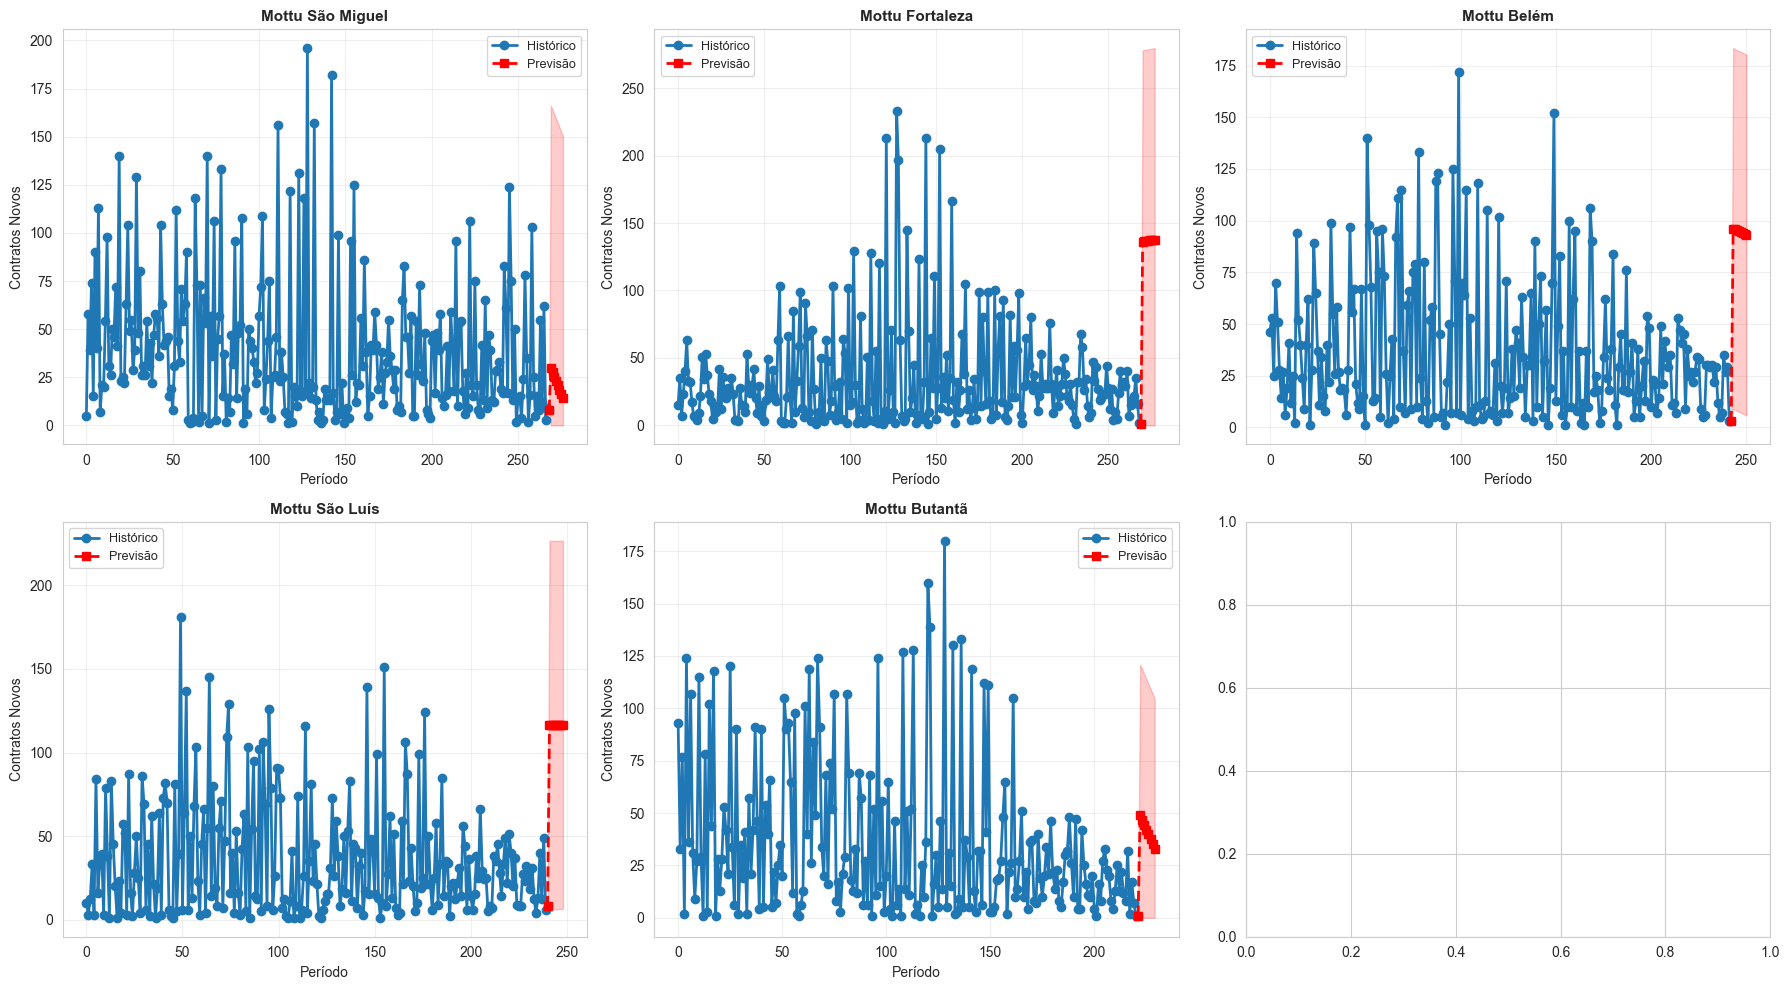

✅ Forecast comparison visualization saved!

📊 Forecast Summary Statistics:
Total locations forecasted: 5
Total periods forecasted: 12

💰 Total predicted contracts (8 weeks):
lugar
Mottu Fortaleza     1095.814011
Mottu São Luís       931.909799
Mottu Belém          756.683333
Mottu Butantã        328.058909
Mottu São Miguel     174.906502
Name: predicted_contratos_novos, dtype: float64


In [9]:
# Create output directory
import os
os.makedirs('data/processed', exist_ok=True)

# Export forecast to CSV
df_forecast.to_csv('data/processed/forecast_8semanas.csv', index=False)
print("✅ Forecast exported to: data/processed/forecast_8semanas.csv")

# Create comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, location in enumerate(top_5_locations[:6]):
    ax = axes[idx]
    
    # Historical data
    hist_data = df_agg_filtered[df_agg_filtered['lugar'] == location].sort_values('periodo_bisemanal')
    hist_periods = np.arange(len(hist_data))
    
    ax.plot(hist_periods, hist_data['contratos_novos'].values, 'o-', 
            label='Histórico', linewidth=2, markersize=6)
    
    # Forecast data
    forecast_data = df_forecast[df_forecast['lugar'] == location].sort_values('periodo_bisemanal')
    if len(forecast_data) > 0:
        forecast_periods = np.arange(len(hist_data) - 1, len(hist_data) - 1 + len(forecast_data) + 1)
        forecast_values = np.concatenate([[hist_data['contratos_novos'].iloc[-1]], 
                                          forecast_data['predicted_contratos_novos'].values])
        
        ax.plot(forecast_periods, forecast_values, 's--', 
                label='Previsão', linewidth=2, markersize=6, color='red')
        
        # Confidence interval
        ax.fill_between(forecast_periods, 
                        np.concatenate([[hist_data['contratos_novos'].iloc[-1]], 
                                      forecast_data['lower_bound'].values]),
                        np.concatenate([[hist_data['contratos_novos'].iloc[-1]], 
                                      forecast_data['upper_bound'].values]),
                        alpha=0.2, color='red')
    
    ax.set_title(f'{location}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Período')
    ax.set_ylabel('Contratos Novos')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/02_forecast_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Forecast comparison visualization saved!")

# Summary statistics
print("\n📊 Forecast Summary Statistics:")
print(f"Total locations forecasted: {df_forecast['lugar'].nunique()}")
print(f"Total periods forecasted: {df_forecast['periodo_bisemanal'].nunique()}")
print(f"\n💰 Total predicted contracts (8 weeks):")
print(df_forecast.groupby('lugar')['predicted_contratos_novos'].sum().sort_values(ascending=False).head(10))